This notebook is used to test different prompt.

---
## SECTION 0 — CONFIG
### Adjust all experiment parameters here before running

In [5]:
# ============================================================
#  CONFIG — Edit this cell to adjust all experiment parameters
# ============================================================
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# --- Model ---
MODEL_ID        = "microsoft/biogpt"          # Zero-shot model (pre-trained only)
#MODEL_CACHE_DIR = r"E:\0000NLP_Models"         
_SHARED_CACHE = r"E:\0000NLP_Models"          # Local cache directory for model weights
MODEL_CACHE_DIR = _SHARED_CACHE if os.path.isdir(_SHARED_CACHE) else None

# --- Input ---
MAX_INPUT_TOKENS = 1024    # BioGPT max context window
TRUNCATION_SIDE  = "right" # Truncate tail of context if over limit ('right' = tail truncation)

# --- Generation (free-text output for case study) ---
MAX_NEW_TOKENS   = 30      # Max tokens to generate for free-text output
TEMPERATURE      = 1.0     # Sampling temperature (1.0 = default, lower = more deterministic)
DO_SAMPLE        = False   # False = greedy decoding (deterministic), True = sampling

# --- Label Consistency (prompt sensitivity test) ---
# Three prompt variants used to test whether label changes with rephrasing
PROMPT_VARIANTS = [
    "As a biomedical expert, review the following context and answer the question.\nQuestion: {question}\nContext: {context}\nAnswer with yes, no, or maybe:",
]

# --- Confidence Margin ---
CONFIDENCE_MARGIN_THRESHOLD = 1.0  # Samples with margin below this are flagged as 'uncertain'

# --- Error Analysis Display ---
TOP_K_ERROR_CASES        = 20      # Number of error cases to display in error analysis
SHOW_LOW_CONFIDENCE_ONLY = False   # True = filter display to only uncertain samples
LENGTH_BUCKET_THRESHOLD  = 512     # Token length above which a sample is considered 'long'

# --- Data ---
DATASET_NAME   = "qiaojin/PubMedQA"
DATASET_CONFIG = "pqa_labeled"
DATASET_SPLIT  = "train"           # PubMedQA labeled set
TEST_SIZE      = 500               # Number of samples to evaluate (set None to use all)
RANDOM_SEED    = 11

# ============================================================
print("Config loaded.")
print(f"  Model        : {MODEL_ID}")
#print(f"  Cache dir    : {MODEL_CACHE_DIR}")
if MODEL_CACHE_DIR:
    print(f"Using shared cache directory: {MODEL_CACHE_DIR}")
else:
    print("Shared cache not found, using HuggingFace default cache.")
print(f"  Max tokens   : {MAX_INPUT_TOKENS}")
print(f"  Margin thresh: {CONFIDENCE_MARGIN_THRESHOLD}")
print(f"  Test samples : {TEST_SIZE}")

Config loaded.
  Model        : microsoft/biogpt
Using shared cache directory: E:\0000NLP_Models
  Max tokens   : 1024
  Margin thresh: 1.0
  Test samples : 500


---
## SECTION 1 — Setup & Imports

In [6]:
import os
import json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import Counter
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from transformers import BioGptTokenizer, BioGptForCausalLM
from datasets import load_dataset
from pubmed_loader import PubMedQAData

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")

Device: cuda
PyTorch version: 2.6.0+cu124


---
## SECTION 2 — Model Loading

> **First run:** downloads ~1.56 GB to `MODEL_CACHE_DIR`. Subsequent runs load from cache instantly.
> 
> The commented block below is for my **teammate Lingshi** running the fine-tuned version.

In [7]:
# ============================================================
#  ZERO-SHOT MODEL — Run this block (default)
#  Model: microsoft/biogpt (pre-trained only, never seen PubMedQA labels)
# ============================================================
print(f"Loading tokenizer and model from '{MODEL_ID}' ...")
print(f"Cache directory: {MODEL_CACHE_DIR}")

tokenizer = BioGptTokenizer.from_pretrained(
    MODEL_ID,
    cache_dir=MODEL_CACHE_DIR
)
model = BioGptForCausalLM.from_pretrained(
    MODEL_ID,
    cache_dir=MODEL_CACHE_DIR
)
model.to(DEVICE)
model.eval()
print("Zero-shot model loaded successfully.")


# ============================================================
#  FINE-TUNED MODEL — For teammate only
#  Uncomment the block below and COMMENT OUT the block above.
#  Model: BioGPT fine-tuned on PubMedQA (supervised generative)
#  Download from: https://msramllasc.blob.core.windows.net/modelrelease/BioGPT/checkpoints/BioGPT-QA-PubMedQA-BioGPT.tgz
#  After downloading, extract and set FINETUNED_MODEL_PATH to the folder path.
# ============================================================
# FINETUNED_MODEL_PATH = r"E:\0000NLP_Models\BioGPT-QA-PubMedQA-BioGPT"
#
# tokenizer = BioGptTokenizer.from_pretrained(FINETUNED_MODEL_PATH)
# model = BioGptForCausalLM.from_pretrained(FINETUNED_MODEL_PATH)
# model.to(DEVICE)
# model.eval()
# print("Fine-tuned model loaded successfully.")
# ============================================================

Loading tokenizer and model from 'microsoft/biogpt' ...
Cache directory: E:\0000NLP_Models


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie biogpt.embed_tokens.weight to output_projection.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Zero-shot model loaded successfully.


In [8]:
# Extract token IDs for the three candidate labels
LABEL_TOKEN_IDS = {
    "yes":   tokenizer.encode("yes",   add_special_tokens=False)[0],
    "no":    tokenizer.encode("no",    add_special_tokens=False)[0],
    "maybe": tokenizer.encode("maybe", add_special_tokens=False)[0],
}
print("Label token IDs:", LABEL_TOKEN_IDS)

Label token IDs: {'yes': 22700, 'no': 102, 'maybe': 22731}


In [9]:
# ============================================================
#  Baseline logit estimation — empty prompt
# ============================================================
LABELS = ["yes", "no", "maybe"]  # add this line

EMPTY_PROMPTS = {
    "empty_string":  "",
    "format_only":   "Answer (yes/no/maybe):",
    "question_only": "Question:\nAnswer (yes/no/maybe):",
    "Prompt_test": "As a biomedical expert, review the following context and answer the question.\nQuestion:\nContext: \nAnswer with (yes/no/maybe):"
}

print("Baseline logits from empty/content-free prompts:\n")
print(f"{'Prompt':<20} {'yes':>8} {'no':>8} {'maybe':>8}   {'argmax':>8}")
print("-" * 60)

baseline_results = {}

for name, prompt in EMPTY_PROMPTS.items():
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        add_special_tokens=True,
    ).to(DEVICE)

    with torch.no_grad():
        logits = model(**inputs).logits[0, -1, :]

    scores = {label: logits[LABEL_TOKEN_IDS[label]].item() for label in LABELS}
    best   = max(scores, key=scores.get)
    baseline_results[name] = scores

    print(f"{name:<20} {scores['yes']:>8.4f} {scores['no']:>8.4f} "
          f"{scores['maybe']:>8.4f}   {best:>8}")

Baseline logits from empty/content-free prompts:

Prompt                    yes       no    maybe     argmax
------------------------------------------------------------
empty_string          -3.4806   1.7393  -1.7883         no
format_only            4.3306   4.2038   0.8841        yes
question_only          4.4709   4.4010   2.4929        yes
Prompt_test            5.9134   4.8665   1.6860        yes


---
## SECTION 3 — Data Loading

In [60]:
dataset = PubMedQAData("data").test_set
print(f"Total samples in dataset: {len(dataset)}")
'''
dataset = load_dataset(DATASET_NAME, DATASET_CONFIG, split=DATASET_SPLIT)
print(f"Total samples in dataset: {len(dataset)}")

# Subsample if TEST_SIZE is set
if TEST_SIZE is not None and TEST_SIZE < len(dataset):
    import random
    random.seed(RANDOM_SEED)
    indices = random.sample(range(len(dataset)), TEST_SIZE)
    dataset = dataset.select(indices)
    print(f"Subsampled to {TEST_SIZE} samples (seed={RANDOM_SEED})")
'''
dataset = [{"id": doc_id, **sample} for doc_id, sample in dataset.items()]
print(f"Total samples in dataset: {len(dataset)}")
print("\nExample:")
print(f"  Question : {dataset[0]['QUESTION'][:100]}...")
print(f"  Label    : {dataset[0]['final_decision']}")

Total samples in dataset: 500
Total samples in dataset: 500

Example:
  Question : Is anorectal endosonography valuable in dyschesia?...
  Label    : yes


---
## SECTION 4 — EDA: Token Length Distribution

Verifies that prompt lengths are within the 1024-token limit.

Counting token lengths: 100%|██████████| 500/500 [00:03<00:00, 144.50it/s]


Prompt token length statistics:
  Mean   : 298.5
  Median : 296.0
  Max    : 573
  Min    : 97
  > 1024 tokens : 0 samples (0.0%)


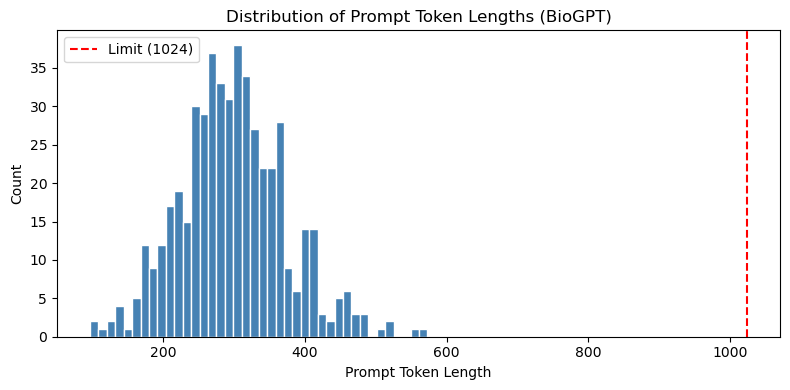

In [61]:
def build_prompt(question, context, variant_idx=0):
    """Build prompt string using the selected variant from PROMPT_VARIANTS."""
    # Join context list to string if needed
    if isinstance(context, list):
        context = " ".join(context)
    template = PROMPT_VARIANTS[variant_idx]
    return template.format(question=question, context=context)


# Count prompt token lengths (variant 0 = primary prompt)
prompt_lengths = []
for sample in tqdm(dataset, desc="Counting token lengths"):
    prompt = build_prompt(sample["QUESTION"], sample["CONTEXTS"])
    token_len = len(tokenizer.encode(prompt))
    prompt_lengths.append(token_len)

prompt_lengths = np.array(prompt_lengths)

print(f"Prompt token length statistics:")
print(f"  Mean   : {prompt_lengths.mean():.1f}")
print(f"  Median : {np.median(prompt_lengths):.1f}")
print(f"  Max    : {prompt_lengths.max()}")
print(f"  Min    : {prompt_lengths.min()}")
print(f"  > {MAX_INPUT_TOKENS} tokens : {(prompt_lengths > MAX_INPUT_TOKENS).sum()} samples "
      f"({(prompt_lengths > MAX_INPUT_TOKENS).mean()*100:.1f}%)")

# Plot distribution
plt.figure(figsize=(8, 4))
plt.hist(prompt_lengths, bins=40, color="steelblue", edgecolor="white")
plt.axvline(MAX_INPUT_TOKENS, color="red", linestyle="--", label=f"Limit ({MAX_INPUT_TOKENS})")
plt.xlabel("Prompt Token Length")
plt.ylabel("Count")
plt.title("Distribution of Prompt Token Lengths (BioGPT)")
plt.legend()
plt.tight_layout()
plt.show()

---
## SECTION 5 — Core Inference Functions

In [62]:
def predict_single(question, context, variant_idx=0):
    """
    Run a single inference on one sample.
    Returns:
        predicted_label   : str  — 'yes', 'no', or 'maybe' (from logit scoring)
        confidence_scores : dict — raw logit values for all three labels
        confidence_margin : float — score(best) - score(second_best)
        generated_text    : str  — free-form generated continuation (for case study)
    """
    prompt = build_prompt(question, context, variant_idx)

    # Tokenize with tail truncation
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_INPUT_TOKENS,
        padding=False,
    ).to(DEVICE)

    with torch.no_grad():
        # --- Logit scoring (constrained label) ---
        logit_outputs = model(**inputs)
        next_token_logits = logit_outputs.logits[0, -1, :]  # last position

        scores = {
            label: next_token_logits[tid].item()
            for label, tid in LABEL_TOKEN_IDS.items()
        }
        sorted_scores = sorted(scores.values(), reverse=True)
        predicted_label   = max(scores, key=scores.get)
        confidence_margin = sorted_scores[0] - sorted_scores[1]

        # --- Free-text generation ---
        gen_ids = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=DO_SAMPLE,
            temperature=TEMPERATURE if DO_SAMPLE else None,
            pad_token_id=tokenizer.eos_token_id,
        )
    
    # Decode only the newly generated tokens
    input_len      = inputs["input_ids"].shape[1]
    generated_ids  = gen_ids[0][input_len:]
    generated_text = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

    return {
        "predicted_label":   predicted_label,
        "confidence_scores": {k: round(v, 4) for k, v in scores.items()},
        "confidence_margin": round(confidence_margin, 4),
        "generated_text":    generated_text,
    }

In [63]:
# Quick sanity check on one sample
sample = dataset[0]
result = predict_single(sample["QUESTION"], sample["CONTEXTS"])

print("=== Sanity Check ===")
print(f"Question       : {sample['QUESTION'][:120]}...")
print(f"True label     : {sample['final_decision']}")
print(f"Predicted label: {result['predicted_label']}")
print(f"Logit scores   : {result['confidence_scores']}")
print(f"Margin         : {result['confidence_margin']}")
print(f"Generated text : {result['generated_text']}")

=== Sanity Check ===
Question       : Is anorectal endosonography valuable in dyschesia?...
True label     : yes
Predicted label: no
Logit scores   : {'yes': 5.5336, 'no': 7.4702, 'maybe': 4.7551}
Margin         : 1.9366
Generated text : "Is anorectal endosonography useful in the diagnosis of dyschesia?"


---
## SECTION 6 — Batch Inference

In [64]:
records = []

for i, sample in enumerate(tqdm(dataset, desc="Running BioGPT inference")):
    question = sample["QUESTION"]
    context  = sample["CONTEXTS"]
    true_label = sample["final_decision"].lower().strip()

    result = predict_single(question, context, variant_idx=0)

    # Token length of this sample's prompt
    prompt     = build_prompt(question, context)
    token_len  = len(tokenizer.encode(prompt))
    truncated  = token_len >= MAX_INPUT_TOKENS

    records.append({
        "idx":               i,
        "question":          question,
        "true_label":        true_label,
        "predicted_label":   result["predicted_label"],
        "correct":           result["predicted_label"] == true_label,
        "score_yes":         result["confidence_scores"]["yes"],
        "score_no":          result["confidence_scores"]["no"],
        "score_maybe":       result["confidence_scores"]["maybe"],
        "confidence_margin": result["confidence_margin"],
        "generated_text":    result["generated_text"],
        "prompt_token_len":  token_len,
        "truncated":         truncated,
    })

df = pd.DataFrame(records)
print(f"Inference complete. Total samples: {len(df)}")
df.head(3)

Running BioGPT inference: 100%|██████████| 500/500 [22:31<00:00,  2.70s/it]

Inference complete. Total samples: 500


,idx,question,true_label,predicted_label,correct,score_yes,score_no,score_maybe,confidence_margin,generated_text,prompt_token_len,truncated
0,0,Is anorectal endosonography valuable in dysche...,yes,no,False,5.5336,7.4702,4.7551,1.9366,"""Is anorectal endosonography useful in the dia...",284,False
1,1,Is there a connection between sublingual varic...,yes,no,False,7.9873,8.4317,3.8930,0.4444,"""There is a connection between sublingual vari...",345,False
2,2,Is the affinity column-mediated immunoassay me...,yes,no,False,7.1175,7.8844,4.0346,0.7668,"""The affinity column-mediated immunoassay meth...",285,False


---
## SECTION 7 — Standard Evaluation Metrics

Identical to main experiment metrics for direct comparison.

In [65]:
y_true = df["true_label"].tolist()
y_pred = df["predicted_label"].tolist()
labels = ["yes", "no", "maybe"]

accuracy    = accuracy_score(y_true, y_pred)
macro_f1    = f1_score(y_true, y_pred, average="macro",    labels=labels, zero_division=0)
weighted_f1 = f1_score(y_true, y_pred, average="weighted", labels=labels, zero_division=0)

print("=" * 45)
print(" BioGPT — Evaluation Results")
print("=" * 45)
print(f"  Accuracy     : {accuracy:.4f}")
print(f"  Macro F1     : {macro_f1:.4f}")
print(f"  Weighted F1  : {weighted_f1:.4f}")
print("\nPer-class Report:")
print(classification_report(y_true, y_pred, labels=labels, zero_division=0))

 BioGPT — Evaluation Results
  Accuracy     : 0.3980
  Macro F1     : 0.2556
  Weighted F1  : 0.3121

Per-class Report:
              precision    recall  f1-score   support

         yes       0.66      0.15      0.25       276
          no       0.36      0.93      0.52       169
       maybe       0.00      0.00      0.00        55

    accuracy                           0.40       500
   macro avg       0.34      0.36      0.26       500
weighted avg       0.48      0.40      0.31       500



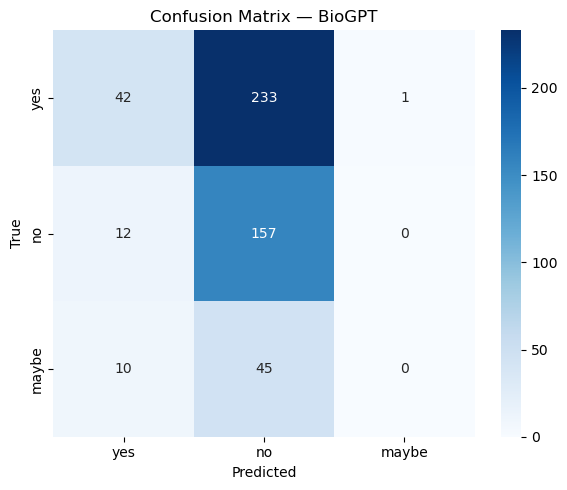

In [66]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — BioGPT")
plt.tight_layout()
plt.show()

---
## SECTION 8 — Generative-Specific Metrics

### Thresholds and parameters are controlled in the CONFIG cell (Section 0)

Three metrics unique to generative models:
1. **Confidence Margin** — How decisive was the model? Low margin = uncertain prediction
2. **Label Consistency** — Does the label change when the prompt is rephrased?
3. **Output Parsability** — Does the free-form generated text contain a valid keyword?

Confidence Margin Threshold : 1.0
Uncertain samples           : 157 (31.4%)
Accuracy on uncertain       : 0.3822
Accuracy on confident       : 0.4052


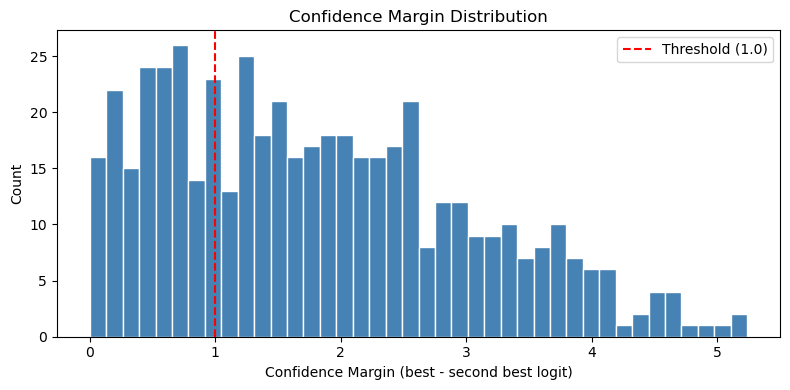

In [67]:
# -------------------------------------------------------
# Metric 1: Confidence Margin
# -------------------------------------------------------
df["uncertain"] = df["confidence_margin"] < CONFIDENCE_MARGIN_THRESHOLD

uncertain_count  = df["uncertain"].sum()
uncertain_pct    = df["uncertain"].mean() * 100
uncertain_acc    = df[df["uncertain"]]["correct"].mean()
confident_acc    = df[~df["uncertain"]]["correct"].mean()

print(f"Confidence Margin Threshold : {CONFIDENCE_MARGIN_THRESHOLD}")
print(f"Uncertain samples           : {uncertain_count} ({uncertain_pct:.1f}%)")
print(f"Accuracy on uncertain       : {uncertain_acc:.4f}")
print(f"Accuracy on confident       : {confident_acc:.4f}")

# Distribution plot
plt.figure(figsize=(8, 4))
plt.hist(df["confidence_margin"], bins=40, color="steelblue", edgecolor="white")
plt.axvline(CONFIDENCE_MARGIN_THRESHOLD, color="red", linestyle="--",
            label=f"Threshold ({CONFIDENCE_MARGIN_THRESHOLD})")
plt.xlabel("Confidence Margin (best - second best logit)")
plt.ylabel("Count")
plt.title("Confidence Margin Distribution")
plt.legend()
plt.tight_layout()
plt.show()

In [68]:
# -------------------------------------------------------
# Metric 3: Output Parsability
# Checks whether the free-form generated text contains a valid keyword
# -------------------------------------------------------
def check_parsability(text):
    t = text.lower().strip()
    if t.startswith("yes"):   return "yes"
    if t.startswith("no"):    return "no"
    if t.startswith("maybe"): return "maybe"
    # Fallback: search anywhere in first 20 chars
    snippet = t[:20]
    for kw in ["yes", "no", "maybe"]:
        if kw in snippet:
            return kw
    return "unparsable"

df["parsed_from_text"] = df["generated_text"].apply(check_parsability)
df["is_parsable"]      = df["parsed_from_text"] != "unparsable"
df["text_label_match"] = df["parsed_from_text"] == df["predicted_label"]

parsability_rate   = df["is_parsable"].mean() * 100
text_match_rate    = df[df["is_parsable"]]["text_label_match"].mean() * 100

print(f"Output Parsability Rate          : {parsability_rate:.1f}%")
print(f"Text-label agreement (parsable)  : {text_match_rate:.1f}%")
print(f"  (agreement = free-text keyword matches logit-scored label)")

# Breakdown
print("\nParsed keyword distribution from free-text:")
print(df["parsed_from_text"].value_counts())

Output Parsability Rate          : 32.6%
Text-label agreement (parsable)  : 90.8%
  (agreement = free-text keyword matches logit-scored label)

Parsed keyword distribution from free-text:
parsed_from_text
unparsable    337
no            146
yes            17
Name: count, dtype: int64


---
## SECTION 9 — Error Analysis

Three analysis dimensions:
1. Error rate **by true label** — which class is hardest?
2. Error rate **by confidence margin** — do uncertain predictions fail more?
3. Error rate **by context length** — do truncated/long samples fail more?

Error rate by true label:
true_label  total  correct  accuracy  error_rate
     maybe     55        0  0.000000    1.000000
        no    169      157  0.928994    0.071006
       yes    276       42  0.152174    0.847826


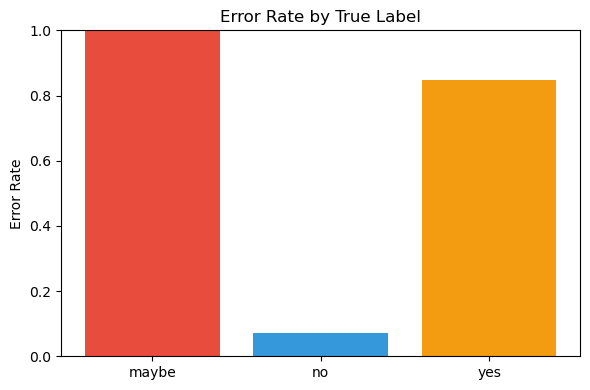

In [69]:
# -------------------------------------------------------
# Dimension 1: Error rate by true label
# -------------------------------------------------------
label_analysis = df.groupby("true_label").agg(
    total=("correct", "count"),
    correct=("correct", "sum"),
    accuracy=("correct", "mean"),
).reset_index()
label_analysis["error_rate"] = 1 - label_analysis["accuracy"]

print("Error rate by true label:")
print(label_analysis.to_string(index=False))

plt.figure(figsize=(6, 4))
plt.bar(label_analysis["true_label"], label_analysis["error_rate"],
        color=["#e74c3c", "#3498db", "#f39c12"])
plt.ylabel("Error Rate")
plt.title("Error Rate by True Label")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [70]:
# -------------------------------------------------------
# Dimension 2: Error rate by confidence margin bucket
# -------------------------------------------------------
df["margin_bucket"] = pd.cut(
    df["confidence_margin"],
    bins=[float("-inf"), 1, 2, 5, float("inf")],
    labels=["< 1 (uncertain)", "1–2", "2–5", "> 5 (confident)"]
)

margin_analysis = df.groupby("margin_bucket", observed=True).agg(
    total=("correct", "count"),
    accuracy=("correct", "mean"),
).reset_index()
margin_analysis["error_rate"] = 1 - margin_analysis["accuracy"]

print("Error rate by confidence margin bucket:")
print(margin_analysis.to_string(index=False))

Error rate by confidence margin bucket:
  margin_bucket  total  accuracy  error_rate
< 1 (uncertain)    157  0.382166    0.617834
            1–2    139  0.388489    0.611511
            2–5    202  0.420792    0.579208
> 5 (confident)      2  0.000000    1.000000


In [71]:
# -------------------------------------------------------
# Dimension 3: Error rate by context length
# -------------------------------------------------------
df["length_bucket"] = df["prompt_token_len"].apply(
    lambda x: f"> {LENGTH_BUCKET_THRESHOLD} (long)" if x > LENGTH_BUCKET_THRESHOLD
    else f"<= {LENGTH_BUCKET_THRESHOLD} (normal)"
)

length_analysis = df.groupby("length_bucket").agg(
    total=("correct", "count"),
    accuracy=("correct", "mean"),
).reset_index()
length_analysis["error_rate"] = 1 - length_analysis["accuracy"]

print("Error rate by prompt token length:")
print(length_analysis.to_string(index=False))

Error rate by prompt token length:
  length_bucket  total  accuracy  error_rate
<= 512 (normal)    496  0.399194    0.600806
   > 512 (long)      4  0.250000    0.750000


In [72]:
# -------------------------------------------------------
# Qualitative case study: Browse error cases
# Toggle SHOW_LOW_CONFIDENCE_ONLY in CONFIG to filter
# -------------------------------------------------------
error_df = df[df["correct"] == False].copy()

if SHOW_LOW_CONFIDENCE_ONLY:
    error_df = error_df[error_df["uncertain"] == True]
    print(f"Showing low-confidence errors only (margin < {CONFIDENCE_MARGIN_THRESHOLD})")

error_df = error_df.sort_values("confidence_margin").head(TOP_K_ERROR_CASES)

print(f"Displaying top {len(error_df)} error cases (sorted by ascending margin):\n")

for _, row in error_df.iterrows():
    print(f"[{row['idx']}] True: {row['true_label']}  Pred: {row['predicted_label']}  "
          f"Margin: {row['confidence_margin']:.3f}")
    print(f"  Scores      : yes={row['score_yes']:.2f}  no={row['score_no']:.2f}  "
          f"maybe={row['score_maybe']:.2f}")
    print(f"  Generated   : {row['generated_text'][:120]}")
    print(f"  Question    : {row['question'][:100]}...")
    print()

Displaying top 20 error cases (sorted by ascending margin):

[123] True: yes  Pred: no  Margin: 0.001
  Scores      : yes=8.27  no=8.27  maybe=4.99
  Generated   : "There is a positive effect of cervical physical therapy on tinnitus complaints in patients with cervicogenic somatic ti
  Question    : Does multi-modal cervical physical therapy improve tinnitus in patients with cervicogenic somatic ti...

[355] True: no  Pred: yes  Margin: 0.044
  Scores      : yes=7.17  no=7.13  maybe=1.68
  Generated   : HBO therapy is beneficial for patients with NF.
  Question    : Necrotizing fasciitis: an indication for hyperbaric oxygenation therapy?...

[96] True: yes  Pred: no  Margin: 0.048
  Scores      : yes=7.02  no=7.07  maybe=4.49
  Generated   : "The prevalence of complex coronary lesions is greater in diabetics than in nondiabetics."
  Question    : Are complex coronary lesions more frequent in patients with diabetes mellitus?...

[259] True: yes  Pred: no  Margin: 0.064
  Scores      : y

---
## SECTION 10 — Results Summary

Final consolidated summary for comparison with main experiment.

In [ ]:
print("=" * 55)
print(" FINAL SUMMARY — BioGPT Zero-Shot Experiment")
print("=" * 55)

print("\n[Standard Metrics]")
print(f"  Accuracy             : {accuracy:.4f}")
print(f"  Macro F1             : {macro_f1:.4f}")
print(f"  Weighted F1          : {weighted_f1:.4f}")

print("\n[Generative-Specific Metrics]")
print(f"  Confidence Margin    : mean={df['confidence_margin'].mean():.3f}  "
      f"median={df['confidence_margin'].median():.3f}")
print(f"  Uncertain samples    : {uncertain_count}/{len(df)} ({uncertain_pct:.1f}%) "
      f"[threshold={CONFIDENCE_MARGIN_THRESHOLD}]")

print(f"  Output Parsability   : {parsability_rate:.1f}% of generated texts contain valid keyword")
print(f"  Text-Label Agreement : {text_match_rate:.1f}% (where parsable)")

print("\n[Data]")
print(f"  Total samples        : {len(df)}")
print(f"  Truncated samples    : {df['truncated'].sum()} ({df['truncated'].mean()*100:.1f}%)")
print(f"  Model                : {MODEL_ID}")
print(f"  Paradigm             : Generative / Zero-Shot")

# Export results to CSV for cross-experiment comparison
output_path = "biogpt_results_prompt_v1_optimized.csv"
df.to_csv(output_path, index=False)
print(f"\nResults saved to: {output_path}")

 FINAL SUMMARY — BioGPT Zero-Shot Experiment

[Standard Metrics]
  Accuracy             : 0.3980
  Macro F1             : 0.2556
  Weighted F1          : 0.3121

[Generative-Specific Metrics]
  Confidence Margin    : mean=1.811  median=1.650
  Uncertain samples    : 157/500 (31.4%) [threshold=1.0]
  Output Parsability   : 32.6% of generated texts contain valid keyword
  Text-Label Agreement : 90.8% (where parsable)

[Data]
  Total samples        : 500
  Truncated samples    : 0 (0.0%)
  Model                : microsoft/biogpt
  Paradigm             : Generative / Zero-Shot

Results saved to: biogpt_results_prompt_v2_optimized.csv
